In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path
from scipy.interpolate import CubicSpline

In [2]:
video_path = "data\Formula_test.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print(f"Resolution : {width} x {height}")
print(f"FPS        : {fps}")
print(f"Frames     : {frame_count}")
print(f"Duration   : {duration} seconds")

Resolution : 1280 x 720
FPS        : 30.0
Frames     : 990
Duration   : 33.0 seconds


In [3]:
# Choose 6 points throughout the video
sample_times = np.linspace(0, duration, 7)

frames = []

for t in sample_times:
    cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000)
    
    ret, frame = cap.read()
    
    if ret:
        frames.append((t, frame))

cap.release()

print(f"Extracted {len(frames)} frames")

Extracted 6 frames


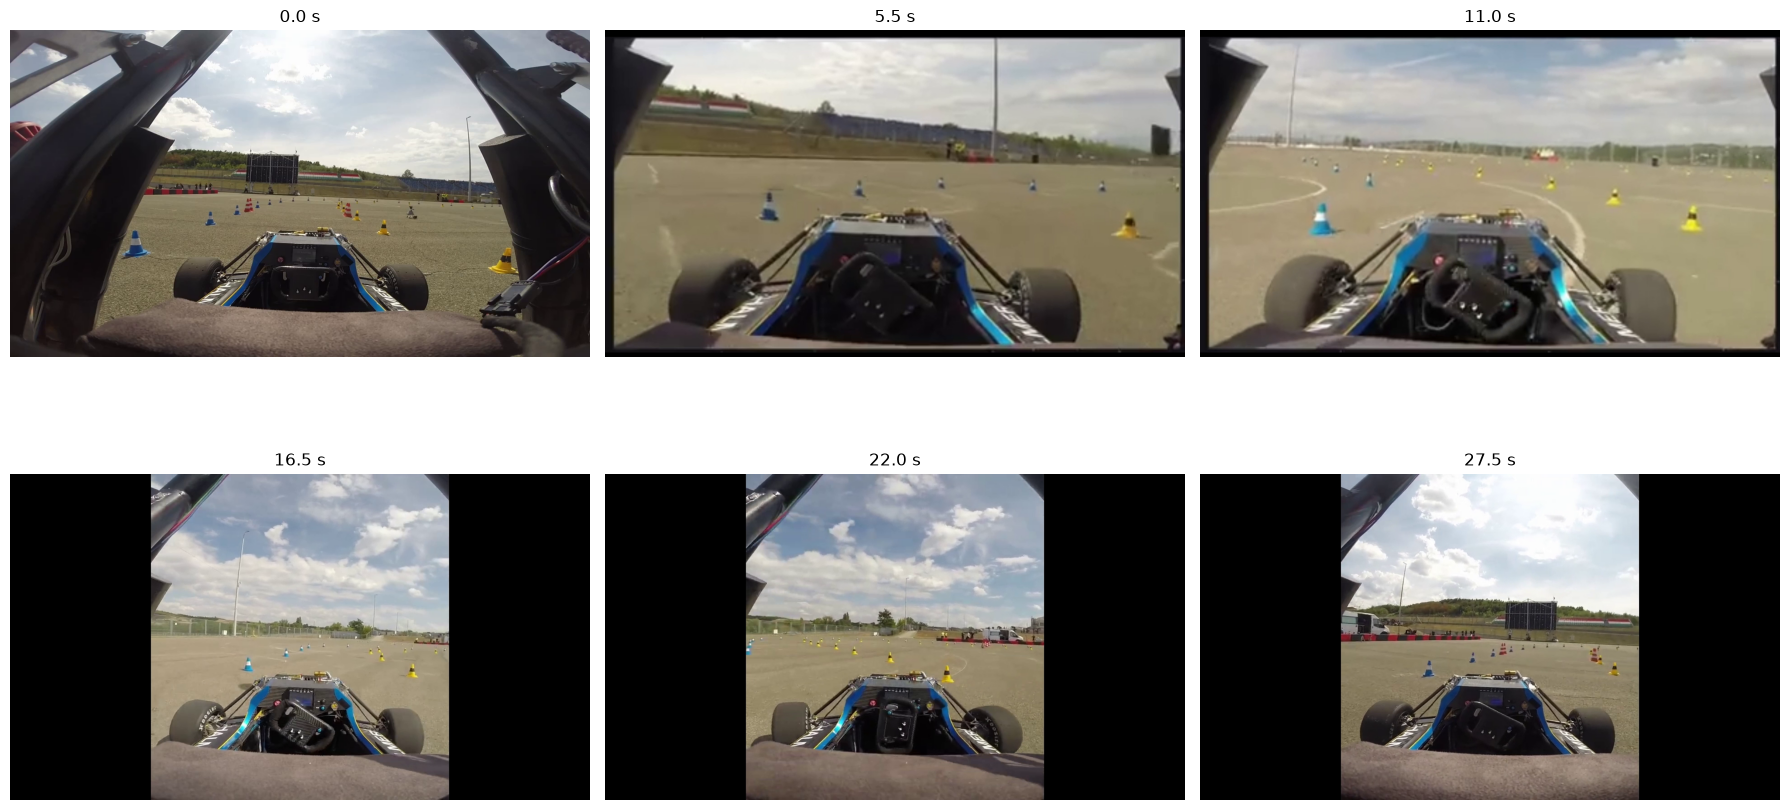

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (t, frame) in zip(axes.ravel(), frames):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ax.imshow(frame_rgb)
    ax.set_title(f"{t:0.1f} s")
    ax.axis("off")

plt.tight_layout()
plt.show()

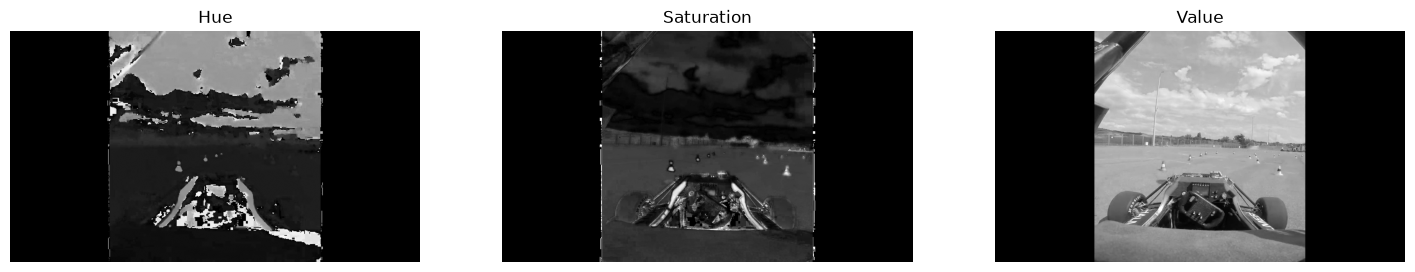

In [5]:
_ ,frame = frames[3]

hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

H, S, V = cv2.split(hsv)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(H, cmap="gray")
axes[0].set_title("Hue")

axes[1].imshow(S, cmap="gray")
axes[1].set_title("Saturation")

axes[2].imshow(V, cmap="gray")
axes[2].set_title("Value")

for ax in axes:
    ax.axis("off")

plt.show()

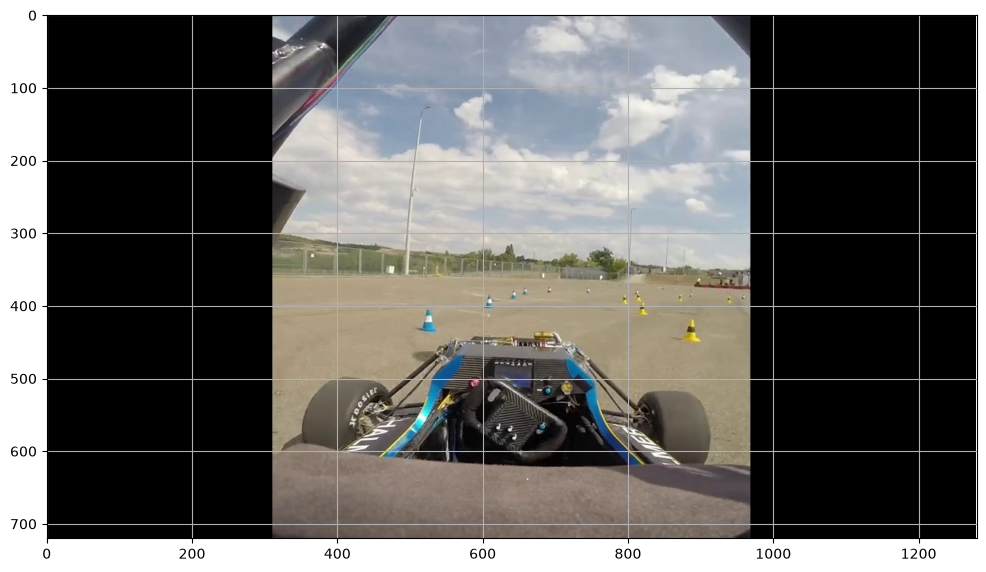

In [6]:
plt.figure(figsize=(12, 7))

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.xlim(0, width)
plt.ylim(height, 0)
plt.grid()

plt.show()

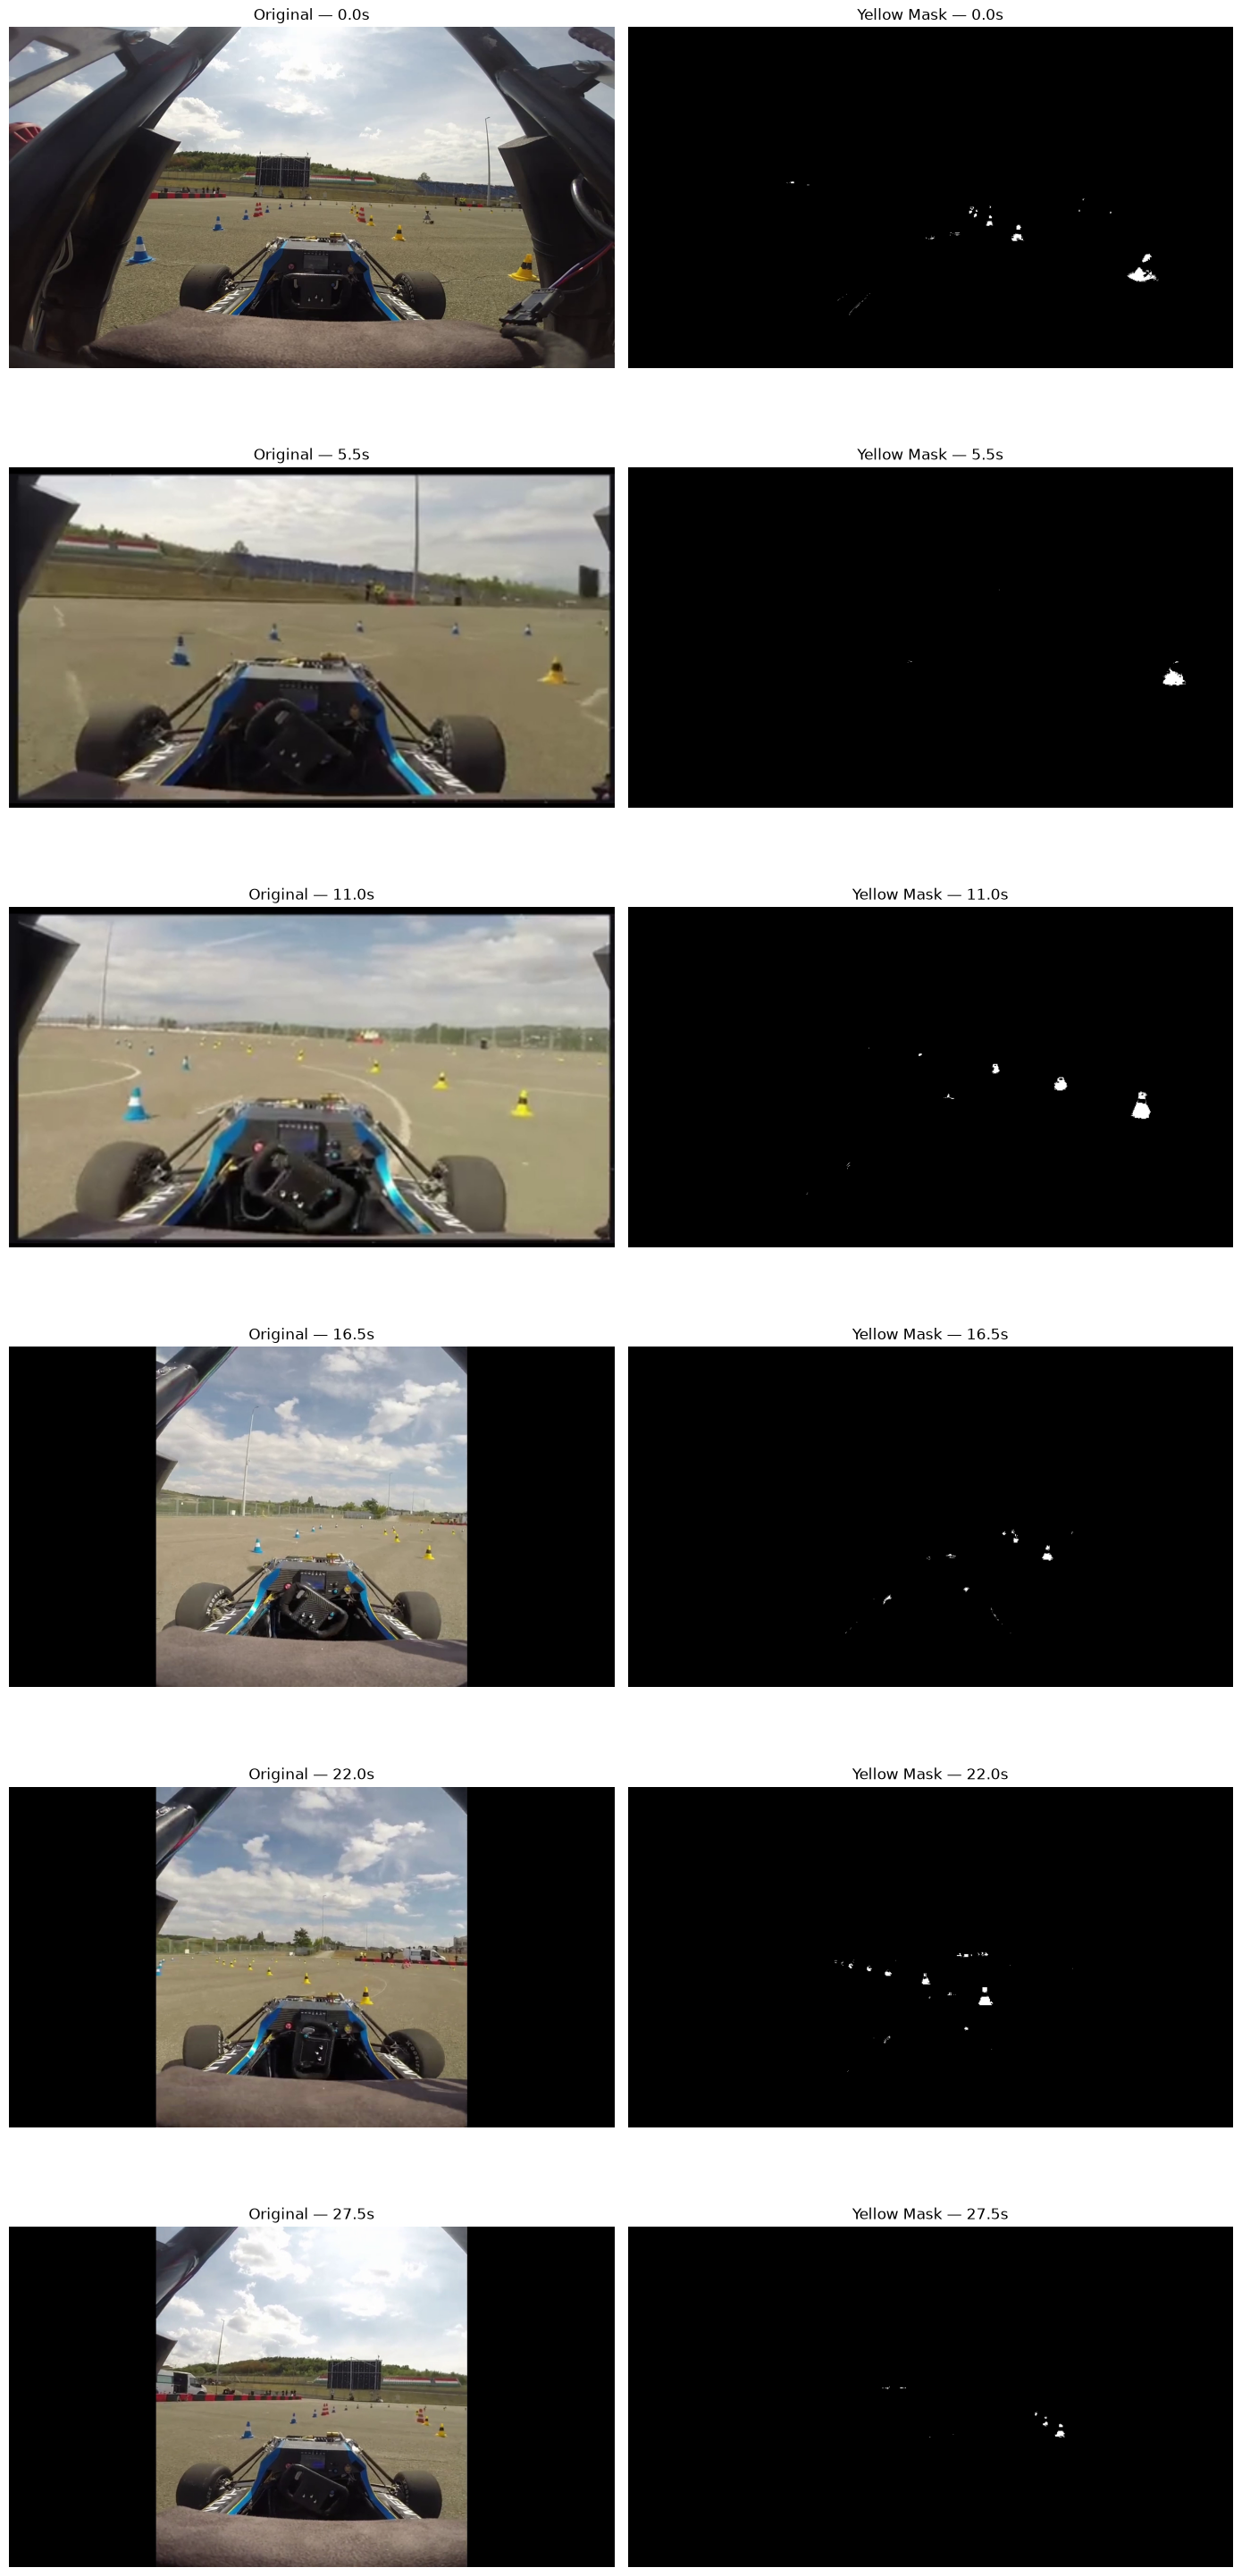

In [7]:
LOWER_YELLOW = np.array([20, 125, 120])
UPPER_YELLOW = np.array([30, 255, 255])


fig, axes = plt.subplots(
    len(frames), 2,
    figsize=(14, 5 * len(frames))
)

for i, (t, frame) in enumerate(frames):

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    yellow_mask = cv2.inRange(hsv, LOWER_YELLOW, UPPER_YELLOW)

    # Normal frame
    axes[i, 0].imshow(
        cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    )
    axes[i, 0].set_title(f"Original — {t:.1f}s")
    axes[i, 0].axis("off")

    # Yellow mask
    axes[i, 1].imshow(
        yellow_mask,
        cmap="gray"
    )
    axes[i, 1].set_title(f"Yellow Mask — {t:.1f}s")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

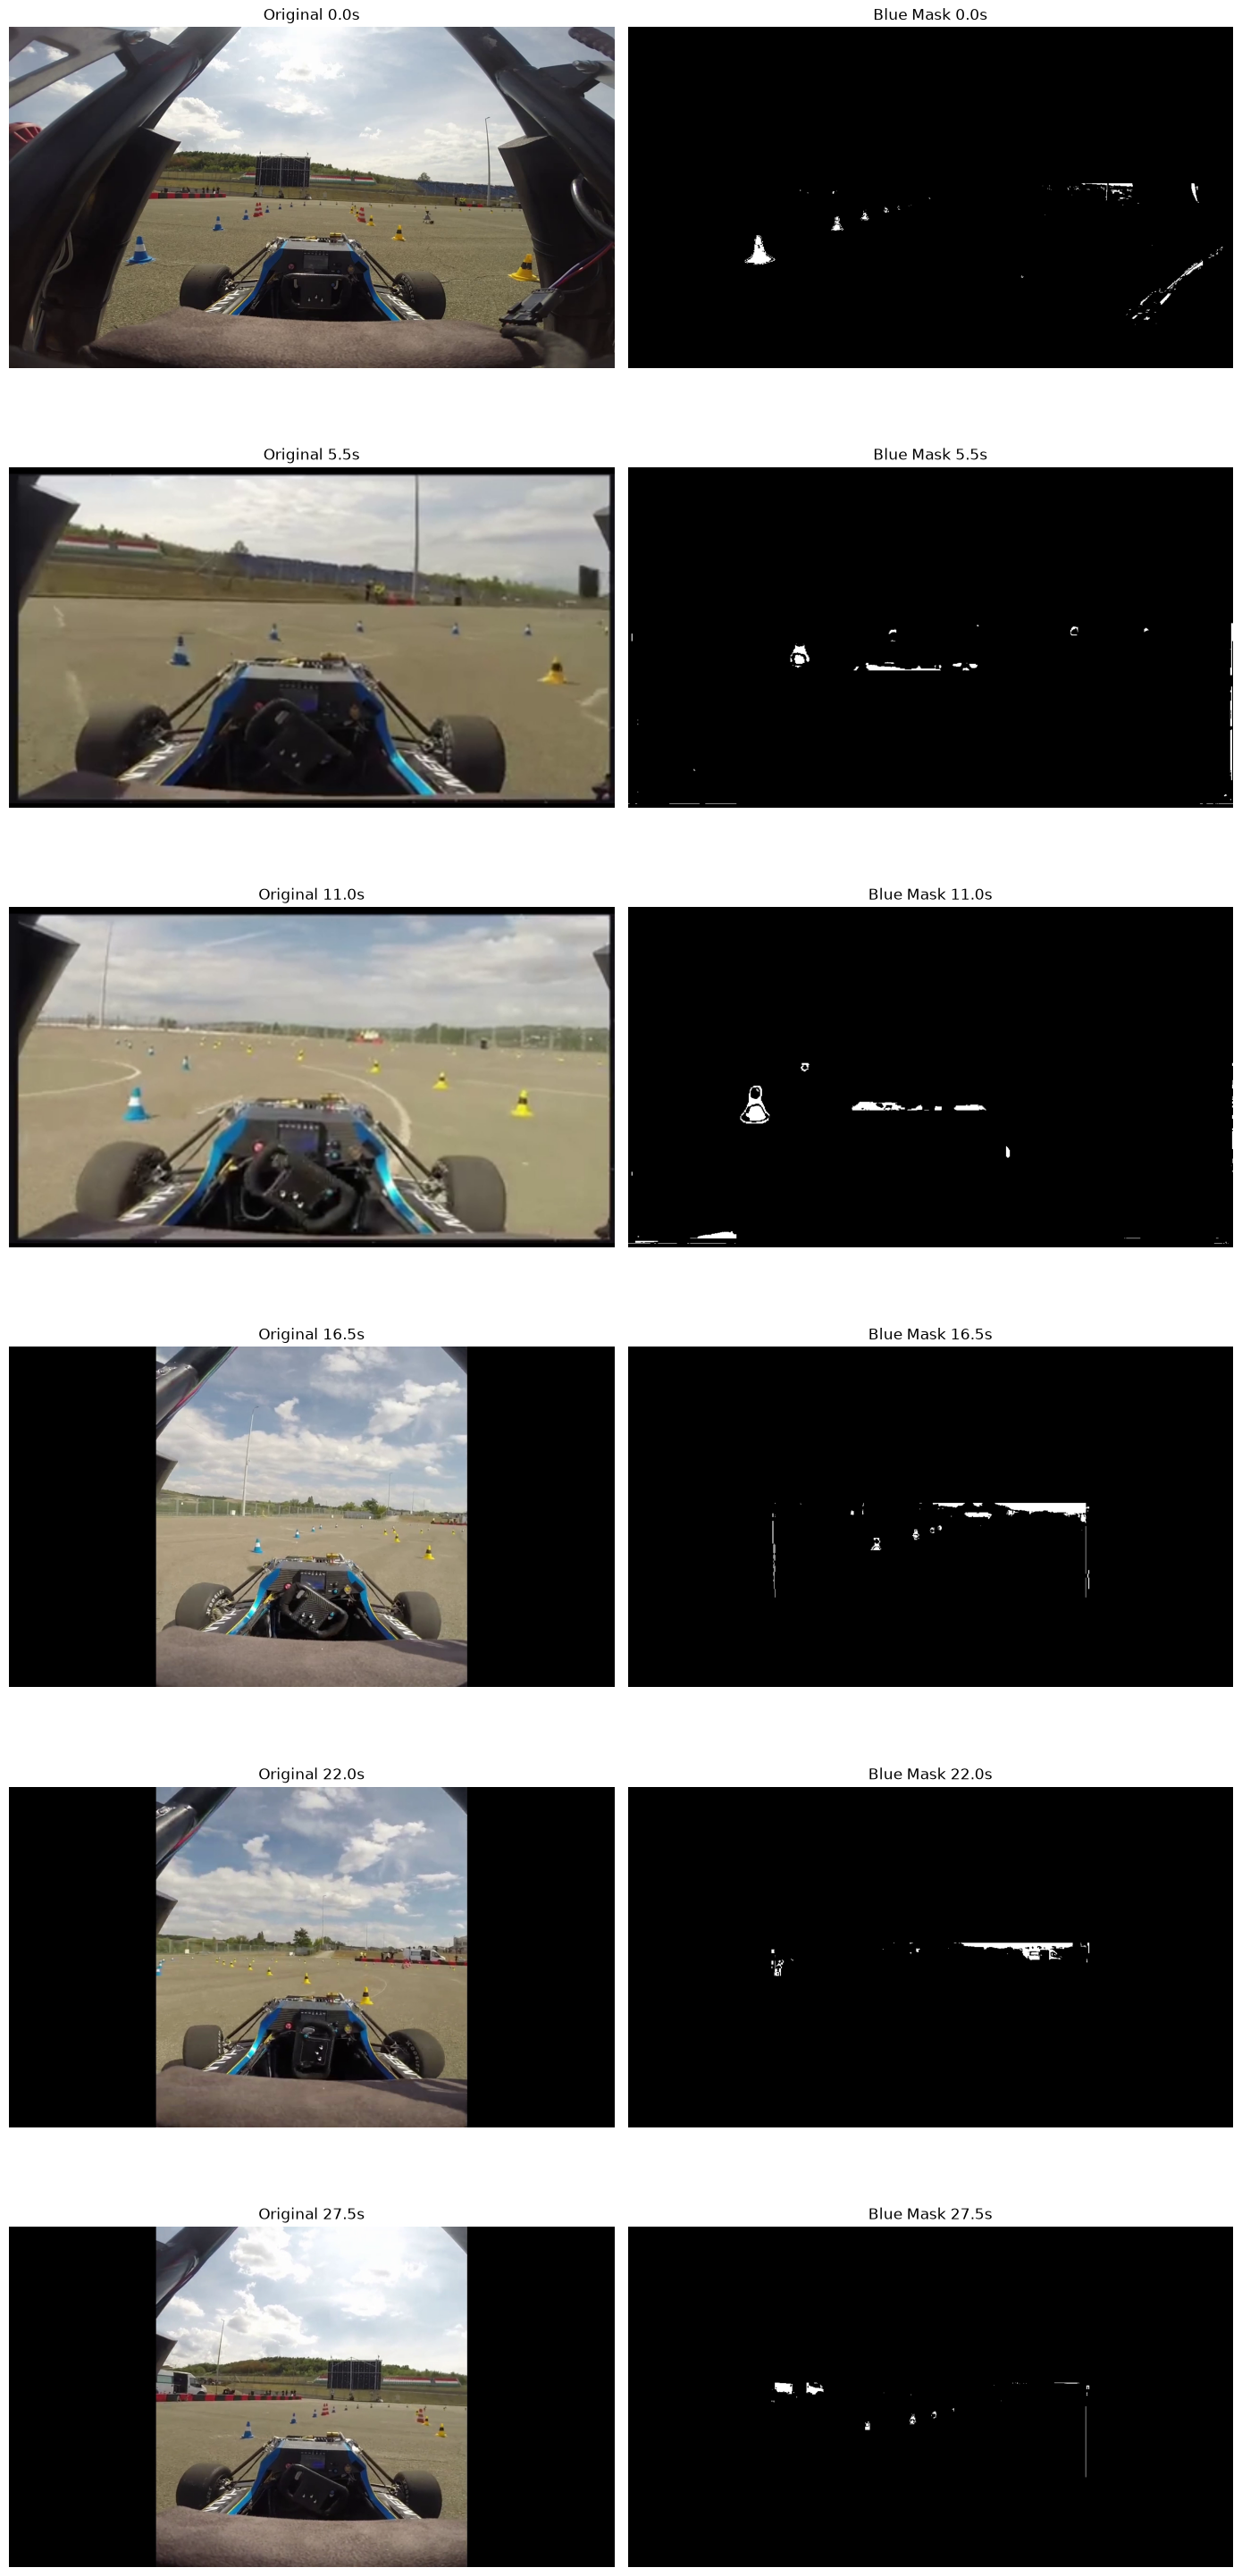

In [8]:
LOWER_BLUE = np.array([94,80,2])
UPPER_BLUE = np.array([140, 255, 255])

LOWER_WHITE = np.array([0, 0, 115])
UPPER_WHITE = np.array([179, 30, 255])


fig, axes = plt.subplots(
    len(frames), 2,
    figsize=(14, 5 * len(frames))
)

for i, (t, frame) in enumerate(frames):

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    
    blue_mask = cv2.inRange(hsv, LOWER_BLUE, UPPER_BLUE)
    white_mask =  cv2.inRange(hsv, LOWER_WHITE, UPPER_WHITE)

    white_mask[:330, :] = 0   ## ignore sky 
    blue_mask[:330, :] = 0

    #ignore car
    white_mask[530:, 230:1050] = 0
    blue_mask[530:, 230:1050] = 0

    white_mask[430:, 400:800] = 0
    blue_mask[430:, 400:800] = 0

    mask = cv2.bitwise_or(blue_mask, white_mask)
    # Normal frame
    axes[i, 0].imshow(
        cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    )
    axes[i, 0].set_title(f"Original {t:.1f}s")
    axes[i, 0].axis("off")

    # blue mask
    axes[i, 1].imshow(
        mask,
        cmap="gray"
    )
    axes[i, 1].set_title(f"Blue Mask {t:.1f}s")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for contour in contours:
    area = cv2.contourArea(contour)

    if area < 10:
        continue

    x, y, w, h = cv2.boundingRect(contour)

    aspect_ratio = h / w

    print(
        "Area:", area,
        "Box:", (x, y, w, h),
        "Aspect:", aspect_ratio
    )

Area: 82.0 Box: (502, 412, 10, 18) Aspect: 1.8
Area: 66.5 Box: (596, 396, 14, 22) Aspect: 1.5714285714285714
Area: 25.5 Box: (644, 390, 9, 12) Aspect: 1.3333333333333333
Area: 18.0 Box: (970, 336, 6, 8) Aspect: 1.3333333333333333
Area: 25.5 Box: (902, 330, 49, 2) Aspect: 0.04081632653061224
Area: 390.5 Box: (377, 330, 37, 25) Aspect: 0.6756756756756757
Area: 633.5 Box: (311, 330, 38, 24) Aspect: 0.631578947368421


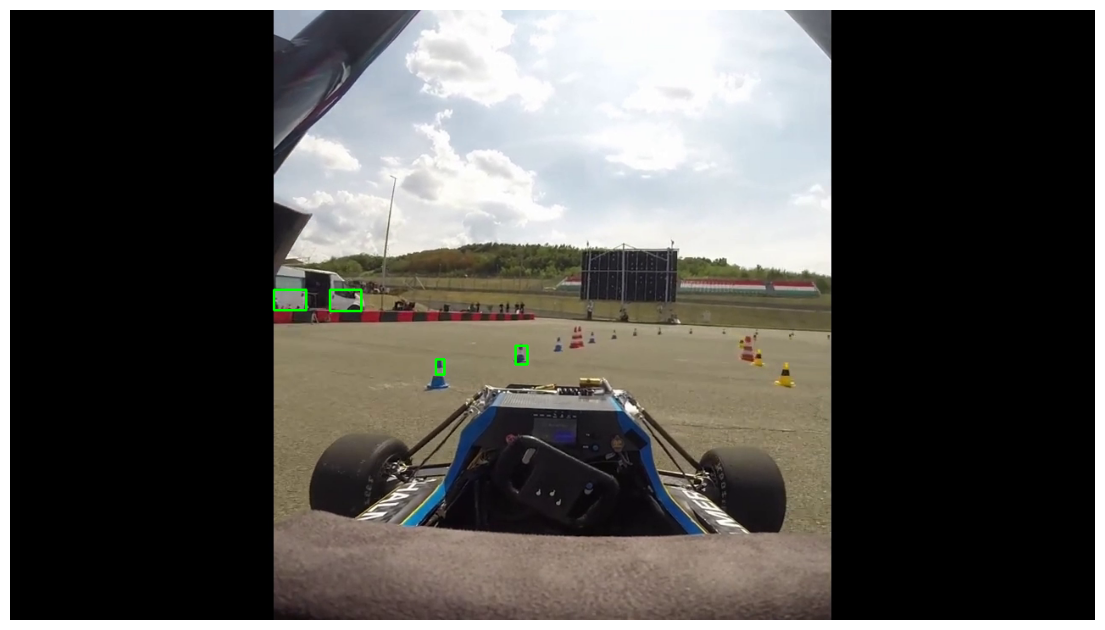

In [10]:
output = frame.copy()

for contour in contours:

    area = cv2.contourArea(contour)

    if area < 50:
        continue

    x, y, w, h = cv2.boundingRect(contour)

    cv2.rectangle(
        output,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [11]:
blue_cones = []

for contour in contours:

    area = cv2.contourArea(contour)

    if area < 20 or area > 500:
        continue

    x, y, w, h = cv2.boundingRect(contour)

    aspect_ratio = h / w

    if aspect_ratio < 0.5 or aspect_ratio > 2.0:
        continue

    blue_cones.append((x, y, w, h))

print("Blue cone candidates:", len(blue_cones))

Blue cone candidates: 4


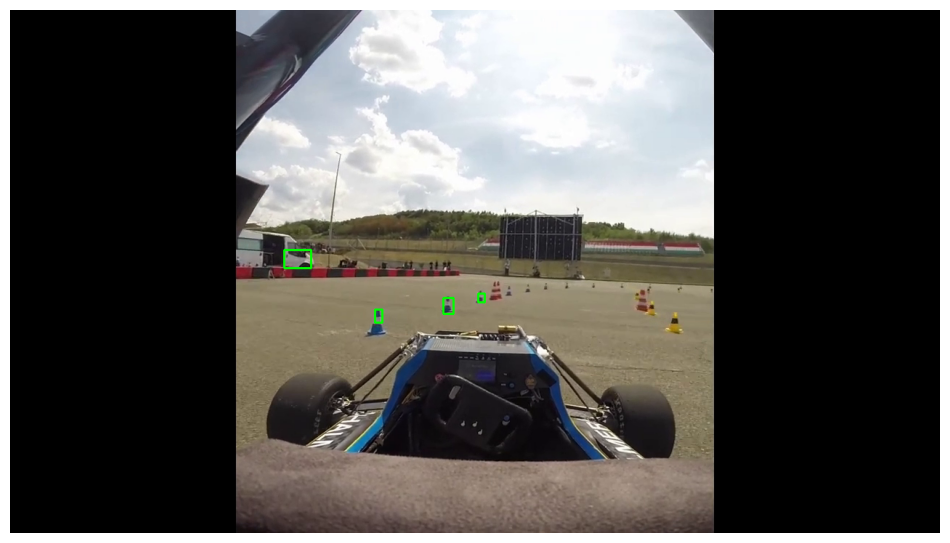

In [12]:
output = frame.copy()

for x, y, w, h in blue_cones:

    cv2.rectangle(
        output,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# now for yellow boxes


In [13]:
yellow_contours, _ = cv2.findContours(
    yellow_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [14]:
yellow_cones = []

for contour in yellow_contours:

    area = cv2.contourArea(contour)

    if area < 20 or area > 500:
        continue

    x, y, w, h = cv2.boundingRect(contour)

    aspect_ratio = h / w

    if aspect_ratio < 0.5 or aspect_ratio > 2.0:
        continue

    yellow_cones.append((x, y, w, h))

print("Yellow cone candidates:", len(yellow_cones))

Yellow cone candidates: 3


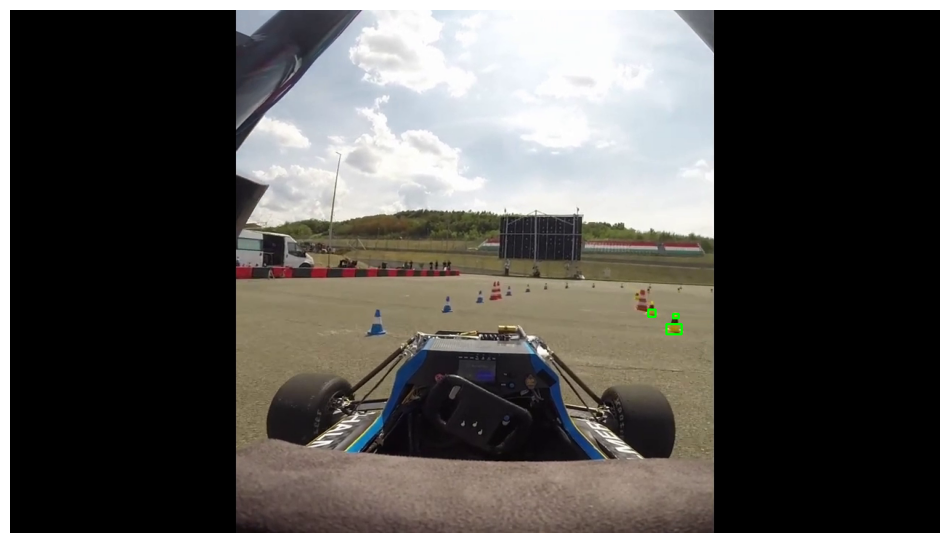

In [15]:
output = frame.copy()

for x, y, w, h in yellow_cones:

    cv2.rectangle(
        output,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [16]:
blue_points = []

for x, y, w, h in blue_cones:

    cx = int(x + w / 2)
    cy = int(y + h)

    blue_points.append((cx, cy))

print("Blue points:", blue_points)

Blue points: [(507, 430), (603, 418), (648, 402), (395, 355)]


In [17]:
yellow_points = []

for x, y, w, h in yellow_cones:

    cx = int(x + w / 2)
    cy = int(y + h)

    yellow_points.append((cx, cy))

print("Yellow points:", yellow_points)

Yellow points: [(913, 446), (916, 424), (883, 422)]


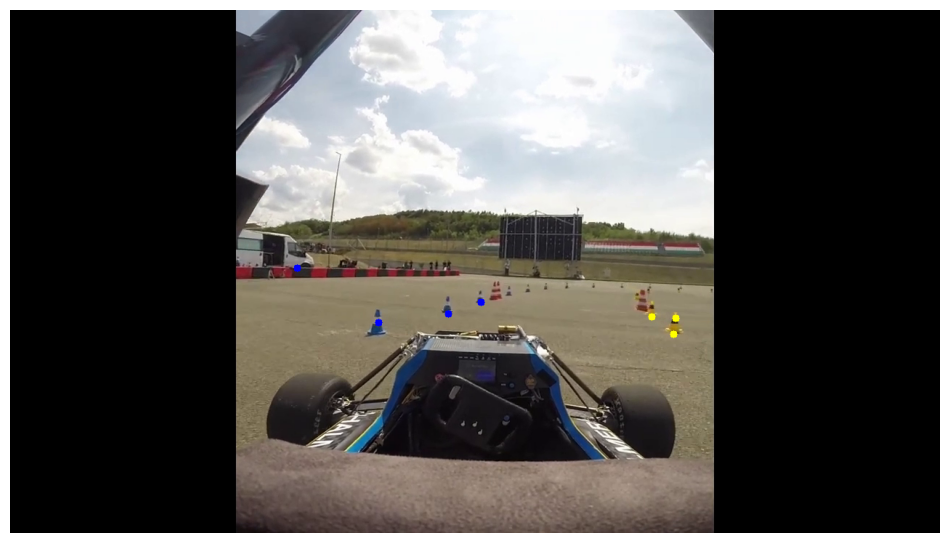

In [18]:
output = frame.copy()

for cx, cy in blue_points:
    cv2.circle(output, (cx, cy), 5, (255, 0, 0), -1)

for cx, cy in yellow_points:
    cv2.circle(output, (cx, cy), 5, (0, 255, 255), -1)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Now we make the function that will process every frame


In [19]:
def detect_conesss(frame2):
    hsv = cv2.cvtColor(frame2, cv2.COLOR_BGR2HSV)

    # masks
    LOWER_YELLOW = np.array([20, 125, 120])
    UPPER_YELLOW = np.array([30, 255, 255])
    
    LOWER_BLUE = np.array([94,80,2])
    UPPER_BLUE = np.array([140, 255, 255])

    LOWER_WHITE = np.array([0, 0, 115])
    UPPER_WHITE = np.array([179, 30, 255])

    
    blue_mask = cv2.inRange(hsv, LOWER_BLUE, UPPER_BLUE)
    white_mask =  cv2.inRange(hsv, LOWER_WHITE, UPPER_WHITE)
    
    #removing noise (sky,car)
    #ignore sky
    white_mask[:330, :] = 0 
    blue_mask[:330, :] = 0

    blue_white_mask = cv2.bitwise_or(blue_mask,white_mask)

    #ignore car
    white_mask[530:, 230:1050] = 0
    blue_mask[530:, 230:1050] = 0
    white_mask[430:, 400:800] = 0
    blue_mask[430:, 400:800] = 0

    #countors
    #for blue+white cones
    blue_white_contours, _ = cv2.findContours(
        blue_white_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    #for yellow cones
    yellow_contours, _ = cv2.findContours(
        yellow_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    #filtering
    blue_white_cones = []
    yellow_cones = []

    for contour in blue_white_contours:

        area = cv2.contourArea(contour)
    
        if area < 20 or area > 500:
            continue
    
        x, y, w, h = cv2.boundingRect(contour)
    
        aspect_ratio = h / w
    
        if aspect_ratio < 0.5 or aspect_ratio > 2.0:
            continue
    
        blue_white_cones.append((x, y, w, h))
        

    for contour in yellow_contours:
    
        area = cv2.contourArea(contour)
    
        if area < 20 or area > 500:
            continue
    
        x, y, w, h = cv2.boundingRect(contour)
    
        aspect_ratio = h / w
    
        if aspect_ratio < 0.5 or aspect_ratio > 2.0:
            continue
    
        yellow_cones.append((x, y, w, h))


    blue_white_points = []

    for x, y, w, h in blue_white_cones:

        cx = int(x + w / 2)
        cy = int(y + h)

        blue_white_points.append((cx, cy))


    yellow_points = []

    for x, y, w, h in yellow_cones:

        cx = int(x + w / 2)
        cy = int(y + h)

        yellow_points.append((cx, cy))

    return blue_white_points,yellow_points
    

In [20]:
def detect_cones(frame2):

    hsv = cv2.cvtColor(frame2, cv2.COLOR_BGR2HSV)

    LOWER_YELLOW = np.array([20, 125, 120])
    UPPER_YELLOW = np.array([30, 255, 255])

    LOWER_BLUE = np.array([94, 80, 2])
    UPPER_BLUE = np.array([140, 255, 255])

    LOWER_WHITE = np.array([0, 0, 115])
    UPPER_WHITE = np.array([179, 30, 255])



    blue_mask = cv2.inRange(
        hsv,
        LOWER_BLUE,
        UPPER_BLUE
    )

    white_mask = cv2.inRange(
        hsv,
        LOWER_WHITE,
        UPPER_WHITE
    )

    yellow_mask = cv2.inRange(
        hsv,
        LOWER_YELLOW,
        UPPER_YELLOW
    )



    blue_mask[:330, :] = 0
    white_mask[:330, :] = 0


    blue_mask[530:, 230:1050] = 0
    white_mask[530:, 230:1050] = 0

    blue_mask[430:, 400:800] = 0
    white_mask[430:, 400:800] = 0


    blue_white_mask = cv2.bitwise_or(
        blue_mask,
        white_mask
    )


    blue_white_contours, _ = cv2.findContours(
        blue_white_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    yellow_contours, _ = cv2.findContours(
        yellow_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )



    blue_white_cones = []

    for contour in blue_white_contours:

        area = cv2.contourArea(contour)

        if area < 20 or area > 500:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        aspect_ratio = h / w

        if aspect_ratio < 0.5 or aspect_ratio > 2.0:
            continue

        blue_white_cones.append(
            (x, y, w, h)
        )


    yellow_cones = []

    for contour in yellow_contours:

        area = cv2.contourArea(contour)

        if area < 20 or area > 500:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        aspect_ratio = h / w

        if aspect_ratio < 0.5 or aspect_ratio > 2.0:
            continue

        yellow_cones.append(
            (x, y, w, h)
        )



    blue_white_points = []

    for x, y, w, h in blue_white_cones:

        cx = int(x + w / 2)
        cy = int(y + h)

        blue_white_points.append(
            (cx, cy)
        )



    yellow_points = []

    for x, y, w, h in yellow_cones:

        cx = int(x + w / 2)
        cy = int(y + h)

        yellow_points.append(
            (cx, cy)
        )


    return blue_white_points, yellow_points

In [ ]:
output_path_cone_detection = "Cone_output_video.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(
    output_path_cone_detection,
    fourcc,
    fps,
    (width, height)
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    blue_points, yellow_points = detect_cones(frame)

    for cx, cy in blue_points:
        cv2.circle(
            frame,
            (cx, cy),
            5,
            (255, 0, 0),
            -1
        )

    for cx, cy in yellow_points:
        cv2.circle(
            frame,
            (cx, cy),
            5,
            (0, 255, 255),
            -1
        )

    out.write(frame)

cap.release()
out.release()

print("Finished!")
print(output_path)

Finished!
Output_video.mp4


## Bird Eye View

Made by AI

In [22]:
src_points = np.float32([
    [330, 350],   # top-left
    [950, 350],   # top-right
    [980, 480],   # bottom-right
    [290, 480]    # bottom-left
])


# Rectangle we want to transform into

dst_points = np.float32([
    [200, 0],      # top-left
    [800, 0],      # top-right
    [800, 600],    # bottom-right
    [200, 600]     # bottom-left
])


# Calculate homography matrix

H = cv2.getPerspectiveTransform(
    src_points,
    dst_points
)

print(H)

[[ 1.39037433e+00  6.77361854e-01 -4.08556150e+02]
 [ 5.80034886e-17  7.37967914e+00 -2.58288770e+03]
 [-9.76208064e-20  1.24777184e-03  1.00000000e+00]]


In [23]:
def transform_points(points, H):

    if len(points) == 0:
        return []

    points_np = np.float32(points).reshape(-1, 1, 2)

    transformed = cv2.perspectiveTransform(
        points_np,
        H
    )

    transformed = transformed.reshape(-1, 2)

    return [
        (int(x), int(y))
        for x, y in transformed
    ]

In [24]:
blue_ground = transform_points(
    blue_points,
    H
)

yellow_ground = transform_points(
    yellow_points,
    H
)

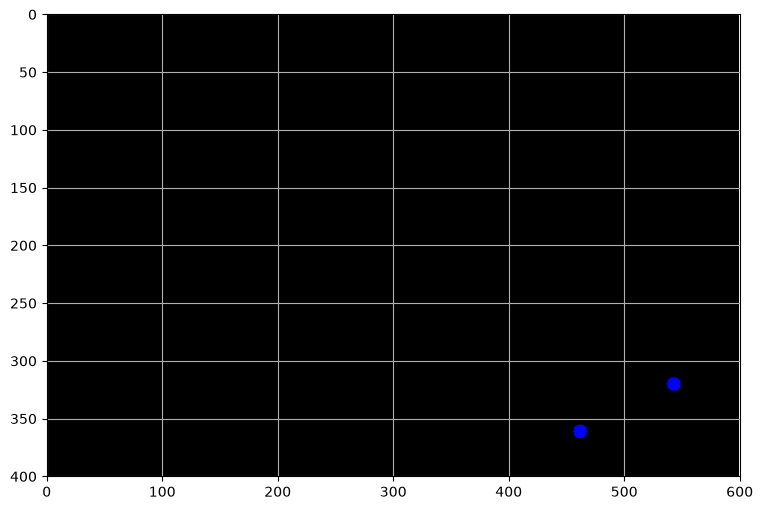

In [25]:
birdseye = np.zeros((400, 600, 3), dtype=np.uint8)

for x, y in blue_ground:
    cv2.circle(birdseye, (x, y), 6, (255, 0, 0), -1)

for x, y in yellow_ground:
    cv2.circle(birdseye, (x, y), 6, (0, 255, 255), -1)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(birdseye, cv2.COLOR_BGR2RGB))
plt.xlim(0, 600)
plt.ylim(400, 0)
plt.grid()
plt.show()

Total frames: 990
Random frame: 812


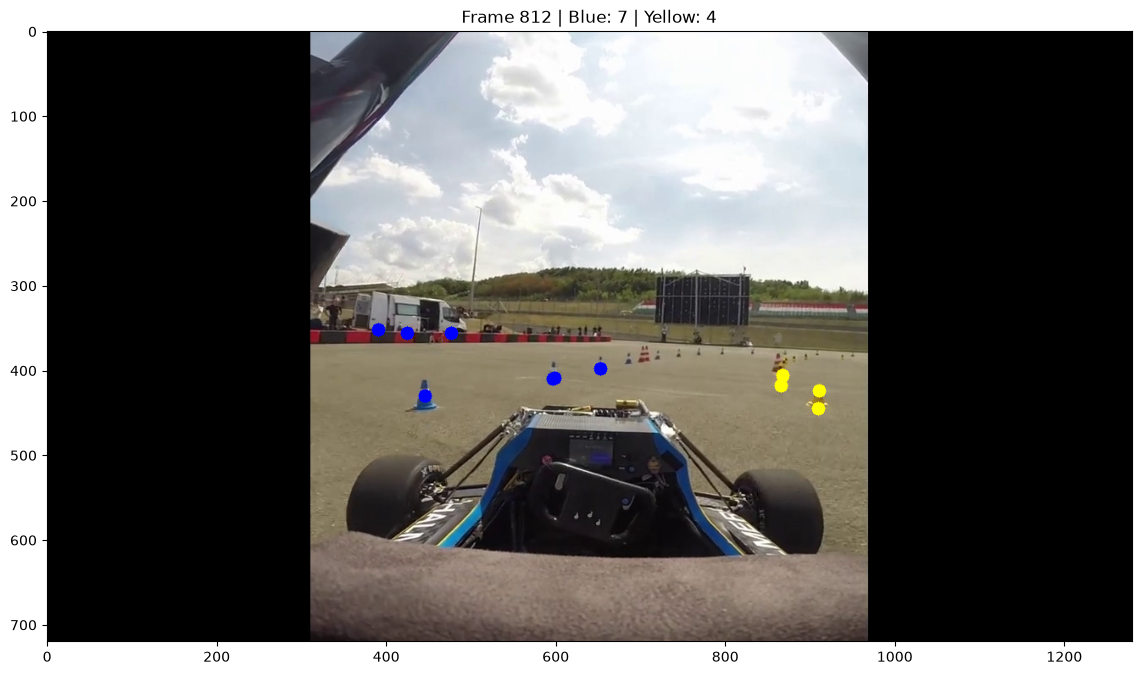


Blue points:
(446, 430)
(597, 410)
(599, 409)
(653, 398)
(425, 356)
(477, 356)
(391, 352)

Yellow points:
(910, 445)
(911, 424)
(866, 418)
(868, 406)


In [26]:
# ==========================================
# PICK A RANDOM FRAME
# ==========================================

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("Could not open video")


# Get total number of frames
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Pick random frame
random_frame_number = random.randint(0, total_frames - 1)

print("Total frames:", total_frames)
print("Random frame:", random_frame_number)


# Jump to random frame
cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_number)

ret, frame = cap.read()

cap.release()


if not ret:
    raise ValueError("Could not read selected frame")


# ==========================================
# RUN YOUR EXISTING CONE DETECTION
# ==========================================

blue_points, yellow_points = detect_cones(frame)


# ==========================================
# DISPLAY FRAME + DETECTION POINTS
# ==========================================

display_frame = frame.copy()


# Blue points
for x, y in blue_points:

    cv2.circle(
        display_frame,
        (x, y),
        8,
        (255, 0, 0),
        -1
    )


# Yellow points
for x, y in yellow_points:

    cv2.circle(
        display_frame,
        (x, y),
        8,
        (0, 255, 255),
        -1
    )


# ==========================================
# SHOW
# ==========================================

plt.figure(figsize=(14, 8))

plt.imshow(
    cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
)

plt.title(
    f"Frame {random_frame_number} | "
    f"Blue: {len(blue_points)} | "
    f"Yellow: {len(yellow_points)}"
)

plt.axis("on")
plt.show()


# ==========================================
# PRINT COORDINATES
# ==========================================

print("\nBlue points:")
for point in blue_points:
    print(point)

print("\nYellow points:")
for point in yellow_points:
    print(point)

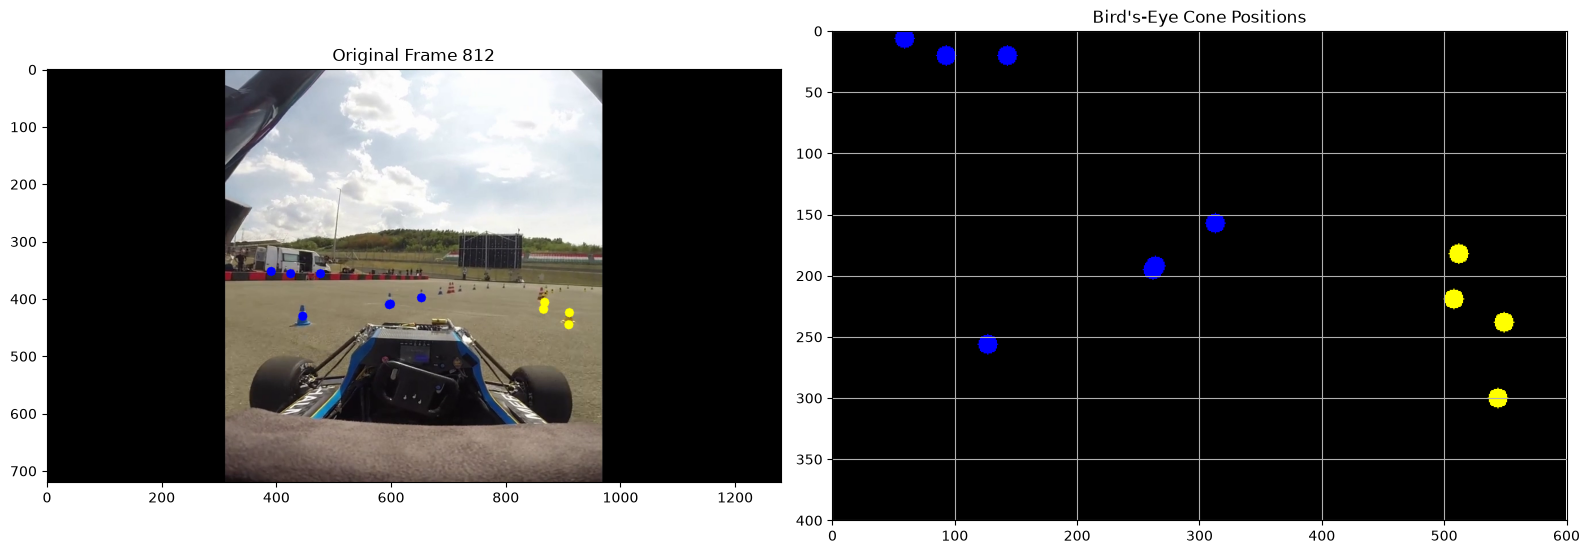


Bird's-eye blue points:
[(127, 256), (262, 195), (264, 192), (313, 157), (93, 20), (143, 20), (59, 6)]

Bird's-eye yellow points:
[(544, 300), (549, 238), (508, 219), (512, 182)]


In [27]:
# ==========================================
# HOMOGRAPHY
# ==========================================

src_points = np.float32([
    [330, 350],   # top-left
    [950, 350],   # top-right
    [980, 480],   # bottom-right
    [290, 480]    # bottom-left
])

dst_points = np.float32([
    [0, 0],
    [600, 0],
    [600, 400],
    [0, 400]
])

H = cv2.getPerspectiveTransform(
    src_points,
    dst_points
)


# ==========================================
# TRANSFORM CONE POINTS
# ==========================================

def transform_points(points, H):

    if len(points) == 0:
        return []

    points_np = np.float32(points).reshape(-1, 1, 2)

    transformed = cv2.perspectiveTransform(
        points_np,
        H
    )

    transformed = transformed.reshape(-1, 2)

    return [
        (int(x), int(y))
        for x, y in transformed
    ]


blue_ground = transform_points(blue_points, H)
yellow_ground = transform_points(yellow_points, H)


# ==========================================
# CREATE BIRD'S-EYE IMAGE
# ==========================================

birdseye = np.zeros((400, 600, 3), dtype=np.uint8)


# Draw blue cones
for x, y in blue_ground:

    cv2.circle(
        birdseye,
        (x, y),
        8,
        (255, 0, 0),
        -1
    )


# Draw yellow cones
for x, y in yellow_ground:

    cv2.circle(
        birdseye,
        (x, y),
        8,
        (0, 255, 255),
        -1
    )


# ==========================================
# SHOW BOTH
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))


# Original frame
axes[0].imshow(
    cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
)

axes[0].set_title(
    f"Original Frame {random_frame_number}"
)

axes[0].axis("on")


# Bird's-eye
axes[1].imshow(
    cv2.cvtColor(birdseye, cv2.COLOR_BGR2RGB)
)

axes[1].set_title("Bird's-Eye Cone Positions")

axes[1].set_xlim(0, 600)
axes[1].set_ylim(400, 0)

axes[1].grid()


plt.tight_layout()
plt.show()


# ==========================================
# PRINT TRANSFORMED COORDINATES
# ==========================================

print("\nBird's-eye blue points:")
print(blue_ground)

print("\nBird's-eye yellow points:")
print(yellow_ground)

In [28]:
left_cones = sorted(blue_ground, key=lambda p: p[1], reverse=True)
right_cones = sorted(yellow_ground, key=lambda p: p[1], reverse=True)

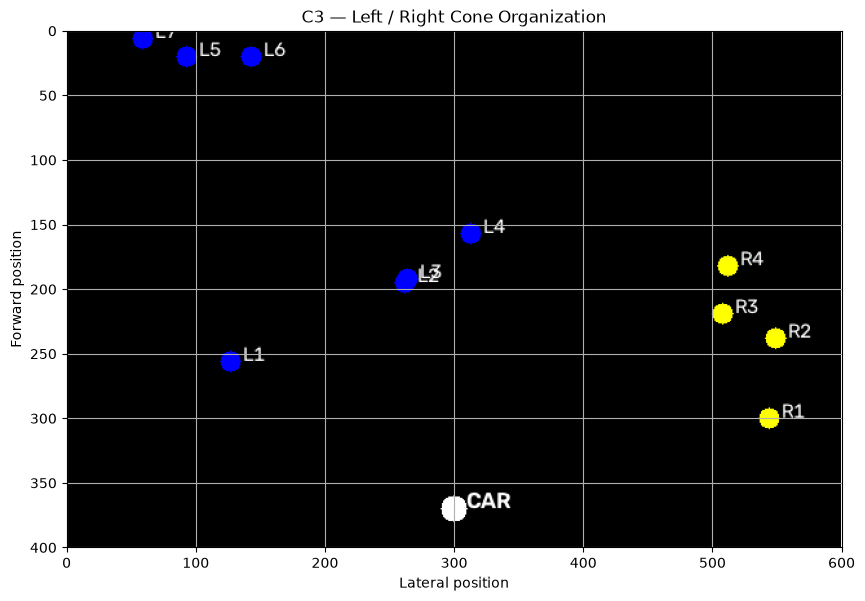

In [29]:
# ==========================================
# C3 — VISUALIZE LEFT / RIGHT
# ==========================================

birdseye = np.zeros((400, 600, 3), dtype=np.uint8)


# Draw LEFT / BLUE cones
for i, (x, y) in enumerate(left_cones):

    cv2.circle(
        birdseye,
        (x, y),
        8,
        (255, 0, 0),
        -1
    )

    cv2.putText(
        birdseye,
        f"L{i+1}",
        (x + 10, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1
    )


# Draw RIGHT / YELLOW cones
for i, (x, y) in enumerate(right_cones):

    cv2.circle(
        birdseye,
        (x, y),
        8,
        (0, 255, 255),
        -1
    )

    cv2.putText(
        birdseye,
        f"R{i+1}",
        (x + 10, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1
    )


# Vehicle center
cv2.circle(
    birdseye,
    (300, 370),
    10,
    (255, 255, 255),
    -1
)

cv2.putText(
    birdseye,
    "CAR",
    (310, 370),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (255, 255, 255),
    2
)


# Display
plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(birdseye, cv2.COLOR_BGR2RGB)
)

plt.title("C3 — Left / Right Cone Organization")

plt.xlim(0, 600)
plt.ylim(400, 0)

plt.xlabel("Lateral position")
plt.ylabel("Forward position")

plt.grid()

plt.show()

In [30]:
blue_ground = transform_points(blue_points, H)
yellow_ground = transform_points(yellow_points, H)

MIN_Y = 100

blue_ground = [
    p for p in blue_ground
    if p[1] >= MIN_Y
]

yellow_ground = [
    p for p in yellow_ground
    if p[1] >= MIN_Y
]

In [31]:
left_cones = blue_ground.copy()
right_cones = yellow_ground.copy()

In [32]:
# ==========================================
# C4 — PREPARE POINTS FOR SPLINE (arc-length parametrized)
# ==========================================


def fit_arc_length_spline(points):
    pts = np.array(points, dtype=float)
    if len(pts) < 3:
        return None

    diffs = np.diff(pts, axis=0)
    seg_lengths = np.sqrt((diffs**2).sum(axis=1))
    t = np.concatenate([[0], np.cumsum(seg_lengths)])

    t_unique, idx = np.unique(t, return_index=True)
    pts_unique = pts[idx]

    if len(t_unique) < 3:
        return None

    spline_x = CubicSpline(t_unique, pts_unique[:, 0])
    spline_y = CubicSpline(t_unique, pts_unique[:, 1])
    return spline_x, spline_y, t_unique

# ------------------------------------------
# LEFT / BLUE
# ------------------------------------------
left_fit = fit_arc_length_spline(left_cones)
if left_fit:
    left_spline_x, left_spline_y, t_left = left_fit
else:
    left_spline_x = left_spline_y = t_left = None

# ------------------------------------------
# RIGHT / YELLOW
# ------------------------------------------
right_fit = fit_arc_length_spline(right_cones)
if right_fit:
    right_spline_x, right_spline_y, t_right = right_fit
else:
    right_spline_x = right_spline_y = t_right = None

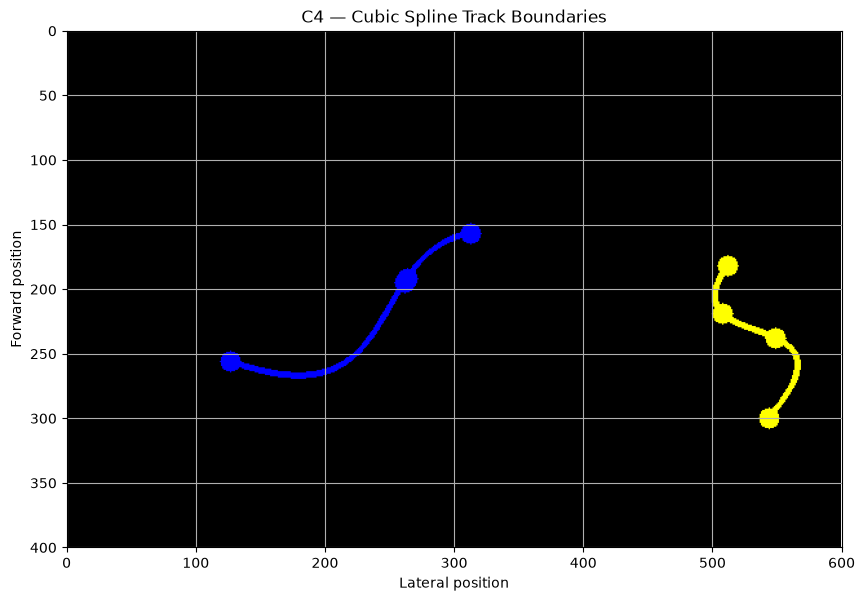

In [33]:
# ==========================================
# C4 — DRAW SPLINE BOUNDARIES
# ==========================================
birdseye = np.zeros(
    (400, 600, 3),
    dtype=np.uint8
)
# ------------------------------------------
# DRAW CONES
# ------------------------------------------
for x, y in left_cones:
    cv2.circle(
        birdseye,
        (x, y),
        8,
        (255, 0, 0),
        -1
    )
for x, y in right_cones:
    cv2.circle(
        birdseye,
        (x, y),
        8,
        (0, 255, 255),
        -1
    )
# ------------------------------------------
# DRAW LEFT SPLINE
# ------------------------------------------
if left_spline_x is not None:
    t_values = np.linspace(
        t_left[0],
        t_left[-1],
        300
    )
    x_values = left_spline_x(t_values)
    y_values = left_spline_y(t_values)
    valid = (
        (x_values >= 0) &
        (x_values < 600) &
        (y_values >= 0) &
        (y_values < 400)
    )
    points = np.column_stack(
        (x_values[valid], y_values[valid])
    ).astype(np.int32)
    if len(points) > 1:
        cv2.polylines(
            birdseye,
            [points],
            False,
            (255, 0, 0),
            3
        )
# ------------------------------------------
# DRAW RIGHT SPLINE
# ------------------------------------------
if right_spline_x is not None:
    t_values = np.linspace(
        t_right[0],
        t_right[-1],
        300
    )
    x_values = right_spline_x(t_values)
    y_values = right_spline_y(t_values)
    valid = (
        (x_values >= 0) &
        (x_values < 600) &
        (y_values >= 0) &
        (y_values < 400)
    )
    points = np.column_stack(
        (x_values[valid], y_values[valid])
    ).astype(np.int32)
    if len(points) > 1:
        cv2.polylines(
            birdseye,
            [points],
            False,
            (0, 255, 255),
            3
        )
# ------------------------------------------
# DISPLAY
# ------------------------------------------
plt.figure(figsize=(10, 7))
plt.imshow(
    cv2.cvtColor(
        birdseye,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("C4 — Cubic Spline Track Boundaries")
plt.xlim(0, 600)
plt.ylim(400, 0)
plt.xlabel("Lateral position")
plt.ylabel("Forward position")
plt.grid()
plt.show()

In [34]:
# ==========================================
# C5 — TRACK CENTERLINE
# ==========================================

# We sample both boundaries at the same forward
# positions and calculate their geometric midpoint.

if (
    left_spline_x is not None
    and left_spline_y is not None
    and right_spline_x is not None
    and right_spline_y is not None
):

    # Sample each boundary
    left_t = np.linspace(
        t_left[0],
        t_left[-1],
        300
    )

    right_t = np.linspace(
        t_right[0],
        t_right[-1],
        300
    )

    left_x = left_spline_x(left_t)
    left_y = left_spline_y(left_t)

    right_x = right_spline_x(right_t)
    right_y = right_spline_y(right_t)

    # Sort each boundary by forward position
    left_order = np.argsort(left_y)
    right_order = np.argsort(right_y)

    left_y = left_y[left_order]
    left_x = left_x[left_order]

    right_y = right_y[right_order]
    right_x = right_x[right_order]

    # Common Y range
    y_min = max(
        left_y.min(),
        right_y.min()
    )

    y_max = min(
        left_y.max(),
        right_y.max()
    )

    # Same forward positions for both boundaries
    center_y = np.linspace(
        y_min,
        y_max,
        200
    )

    # Interpolate boundary X positions
    center_left_x = np.interp(
        center_y,
        left_y,
        left_x
    )

    center_right_x = np.interp(
        center_y,
        right_y,
        right_x
    )

    # Geometric midpoint
    center_x = (
        center_left_x +
        center_right_x
    ) / 2

    centerline = np.column_stack(
        (center_x, center_y)
    )

else:

    centerline = None


print("Centerline calculated:", centerline is not None)

Centerline calculated: True


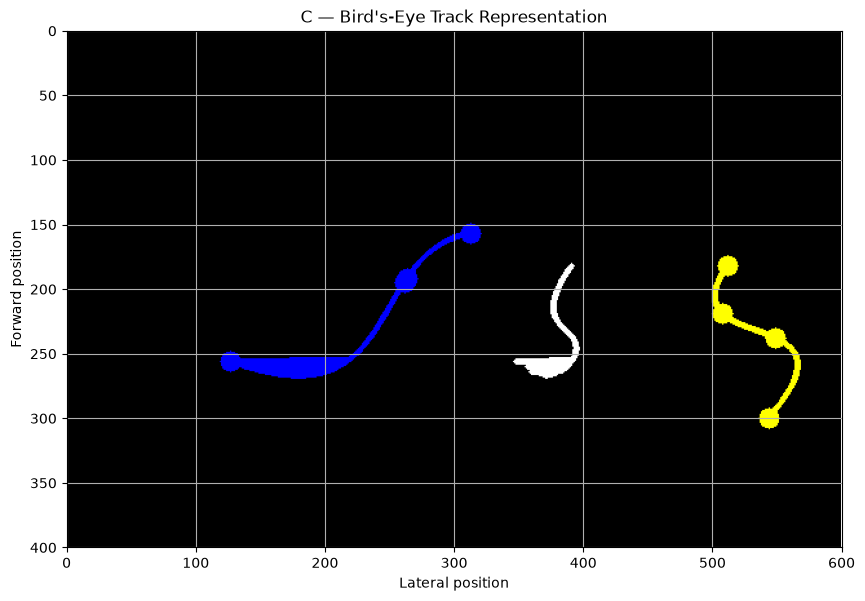

In [35]:
# ==========================================
# C5 — FINAL BEV REPRESENTATION
# ==========================================

birdseye = np.zeros(
    (400, 600, 3),
    dtype=np.uint8
)


# Blue cones
for x, y in left_cones:

    cv2.circle(
        birdseye,
        (x, y),
        8,
        (255, 0, 0),
        -1
    )


# Yellow cones
for x, y in right_cones:

    cv2.circle(
        birdseye,
        (x, y),
        8,
        (0, 255, 255),
        -1
    )


# Left boundary
if left_spline_x is not None:

    pts = np.column_stack(
        (
            left_x,
            left_y
        )
    ).astype(np.int32)

    cv2.polylines(
        birdseye,
        [pts],
        False,
        (255, 0, 0),
        3
    )


# Right boundary
if right_spline_x is not None:

    pts = np.column_stack(
        (
            right_x,
            right_y
        )
    ).astype(np.int32)

    cv2.polylines(
        birdseye,
        [pts],
        False,
        (0, 255, 255),
        3
    )


# Centerline
if centerline is not None:

    pts = centerline.astype(np.int32)

    # Keep only points inside the BEV
    valid = (
        (pts[:, 0] >= 0) &
        (pts[:, 0] < 600) &
        (pts[:, 1] >= 0) &
        (pts[:, 1] < 400)
    )

    pts = pts[valid]

    if len(pts) > 1:

        cv2.polylines(
            birdseye,
            [pts],
            False,
            (255, 255, 255),
            4
        )


# Display
plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(
        birdseye,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "C — Bird's-Eye Track Representation"
)

plt.xlim(0, 600)
plt.ylim(400, 0)

plt.xlabel("Lateral position")
plt.ylabel("Forward position")

plt.grid()

plt.show()

In [36]:
def point_inside_roi(point, roi):
    """ Check whether a point lies inside the quadrilateral ROI. """ 

    contour = roi.astype(np.float32).reshape((-1, 1, 2))
    result = cv2.pointPolygonTest( contour, (float(point[0]), float(point[1])), False ) 

    return result >= 0

In [38]:
# ==========================================
# C — GENERATE BIRD'S-EYE VIDEO
# ==========================================

output_path = "bird_eye.mp4"


# ------------------------------------------
# VIDEO SETUP
# ------------------------------------------

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("Could not open video")

fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (600, 400)
)


# ------------------------------------------
# PROCESS EVERY FRAME
# ------------------------------------------

frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1


    # ======================================
    # B7 CONE DETECTION
    # ======================================

    blue_points, yellow_points = detect_cones(frame)


    # ======================================
    # HOMOGRAPHY
    # ======================================

    blue_points_filtered = [
        p for p in blue_points
        if point_inside_roi(p, src_points)
    ]

    yellow_points_filtered = [
        p for p in yellow_points
        if point_inside_roi(p, src_points)
    ]


    blue_ground = transform_points(
        blue_points_filtered,
        H
    )

    yellow_ground = transform_points(
        yellow_points_filtered,
        H
    )


    # ======================================
    # REMOVE VERY FAR POINTS
    # ======================================

    MIN_Y = 100

    left_cones = [
        p for p in blue_ground
        if p[1] >= MIN_Y
    ]

    right_cones = [
        p for p in yellow_ground
        if p[1] >= MIN_Y
    ]


    # ======================================
    # SORT CONES
    # ======================================

    left_cones.sort(
        key=lambda p: p[1]
    )

    right_cones.sort(
        key=lambda p: p[1]
    )


    # ======================================
    # CREATE BEV
    # ======================================

    birdseye = np.zeros(
        (400, 600, 3),
        dtype=np.uint8
    )


    # ======================================
    # DRAW CONES
    # ======================================

    for x, y in left_cones:

        cv2.circle(
            birdseye,
            (x, y),
            8,
            (255, 0, 0),
            -1
        )


    for x, y in right_cones:

        cv2.circle(
            birdseye,
            (x, y),
            8,
            (0, 255, 255),
            -1
        )


    # ======================================
    # INITIALIZE SPLINES
    # ======================================

    left_spline_x = None
    left_spline_y = None

    right_spline_x = None
    right_spline_y = None

    left_x = None
    left_y = None

    right_x = None
    right_y = None

    centerline = None


    # ======================================
    # LEFT BOUNDARY
    # ======================================

    if len(left_cones) >= 3:

        left_array = np.array(
            left_cones,
            dtype=float
        )

        left_array = left_array[
            np.argsort(left_array[:, 1])
        ]

        t = np.arange(
            len(left_array)
        )

        left_spline_x = CubicSpline(
            t,
            left_array[:, 0]
        )

        left_spline_y = CubicSpline(
            t,
            left_array[:, 1]
        )

        t_fine = np.linspace(
            0,
            len(left_array) - 1,
            200
        )

        left_x = left_spline_x(t_fine)
        left_y = left_spline_y(t_fine)

        left_points = np.column_stack(
            (
                left_x,
                left_y
            )
        ).astype(np.int32)

        valid = (
            (left_points[:, 0] >= 0) &
            (left_points[:, 0] < 600) &
            (left_points[:, 1] >= 0) &
            (left_points[:, 1] < 400)
        )

        left_points = left_points[valid]

        if len(left_points) > 1:

            cv2.polylines(
                birdseye,
                [left_points],
                False,
                (255, 0, 0),
                3
            )


    # ======================================
    # RIGHT BOUNDARY
    # ======================================

    if len(right_cones) >= 3:

        right_array = np.array(
            right_cones,
            dtype=float
        )

        right_array = right_array[
            np.argsort(right_array[:, 1])
        ]

        t = np.arange(
            len(right_array)
        )

        right_spline_x = CubicSpline(
            t,
            right_array[:, 0]
        )

        right_spline_y = CubicSpline(
            t,
            right_array[:, 1]
        )

        t_fine = np.linspace(
            0,
            len(right_array) - 1,
            200
        )

        right_x = right_spline_x(t_fine)
        right_y = right_spline_y(t_fine)

        right_points = np.column_stack(
            (
                right_x,
                right_y
            )
        ).astype(np.int32)

        valid = (
            (right_points[:, 0] >= 0) &
            (right_points[:, 0] < 600) &
            (right_points[:, 1] >= 0) &
            (right_points[:, 1] < 400)
        )

        right_points = right_points[valid]

        if len(right_points) > 1:

            cv2.polylines(
                birdseye,
                [right_points],
                False,
                (0, 255, 255),
                3
            )


    # ======================================
    # CENTERLINE
    # ======================================

    if (
        left_spline_x is not None
        and right_spline_x is not None
    ):

        # Use the shorter spline range
        common_length = min(
            len(left_array),
            len(right_array)
        )

        if common_length >= 2:

            t_center = np.linspace(
                0,
                common_length - 1,
                200
            )

            # Evaluate left boundary
            center_left_x = left_spline_x(
                t_center
            )

            center_left_y = left_spline_y(
                t_center
            )

            # Evaluate right boundary
            center_right_x = right_spline_x(
                t_center
            )

            center_right_y = right_spline_y(
                t_center
            )

            # Midpoint between boundaries
            center_x = (
                center_left_x +
                center_right_x
            ) / 2.0

            center_y = (
                center_left_y +
                center_right_y
            ) / 2.0

            centerline = np.column_stack(
                (
                    center_x,
                    center_y
                )
            )


    # ======================================
    # DRAW CENTERLINE
    # ======================================

    if centerline is not None:

        pts = centerline.astype(
            np.int32
        )

        # Keep only points inside BEV
        valid = (
            (pts[:, 0] >= 0) &
            (pts[:, 0] < 600) &
            (pts[:, 1] >= 0) &
            (pts[:, 1] < 400)
        )

        pts = pts[valid]

        if len(pts) > 1:

            cv2.polylines(
                birdseye,
                [pts],
                False,
                (255, 255, 255),
                4
            )


    # ======================================
    # WRITE BEV FRAME
    # ======================================

    writer.write(
        birdseye
    )


    # --------------------------------------
    # PROGRESS
    # --------------------------------------

    if frame_number % 100 == 0:

        print(
            f"Processed {frame_number} frames"
        )


# ------------------------------------------
# FINISH
# ------------------------------------------

cap.release()
writer.release()

print("\nDone!")
print("Output:", output_path)

Processed 100 frames
Processed 200 frames
Processed 300 frames
Processed 400 frames
Processed 500 frames
Processed 600 frames
Processed 700 frames
Processed 800 frames
Processed 900 frames

Done!
Output: bird_eye.mp4
